<a href="https://colab.research.google.com/github/cibi-ruba-arasu/Machine_Learning_from_Scratch/blob/main/Logistic_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Logistic Regression**

https://www.youtube.com/watch?v=EKm0spFxFG4

In [225]:
import pandas as pd
from sklearn.preprocessing import OrdinalEncoder
from matplotlib import pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

d = {'miles_per_week': [37,39,46,51,88,17,18,20,21,22,23,24,25,27,28,29,30,31,32,33,34,38,40,42,57,68,35,36,41,43,45,47,49,50,52,53,54,55,56,58,59,60,61,63,64,65,66,69,70,72,73,75,76,77,78,80,81,82,83,84,85,86,87,89,91,92,93,95,96,97,98,99,100,101,102,103,104,105,106,107,109,110,111,113,114,115,116,116,118,119,120,121,123,124,126,62,67,74,79,90,112],
      'completed_50m_ultra': ['no','no','no','no','no','no','no','no','no','no','no','no','no','no','no','no','no','no','no','no','no','no','no','no','no','no','yes','yes','yes','yes','no','yes','yes','yes','no','yes','yes','yes','yes','yes','yes','yes','yes','no','yes','yes','yes','yes','yes','yes','yes','no','yes','yes','yes','yes','yes','yes','yes','no','yes','yes','yes','yes','yes','yes','yes','no','yes','yes','yes','yes','yes','yes','yes','yes','yes','yes','yes','yes','yes','yes','yes','yes','yes','yes','yes','yes','yes','yes','yes','yes','yes','yes','yes','yes','yes','yes','yes','yes','yes',]}

df = pd.DataFrame(data=d)
df

,miles_per_week,completed_50m_ultra
0,37,no
1,39,no
2,46,no
3,51,no
4,88,no
...,...,...
96,67,yes
97,74,yes
98,79,yes
99,90,yes


In [226]:
finished_race = ['no', 'yes'] #no = 0, yes = 1

enc = OrdinalEncoder(categories = [finished_race])

df['completed_50m_ultra'] = enc.fit_transform(df[['completed_50m_ultra']])

df

,miles_per_week,completed_50m_ultra
0,37,0.0
1,39,0.0
2,46,0.0
3,51,0.0
4,88,0.0
...,...,...
96,67,1.0
97,74,1.0
98,79,1.0
99,90,1.0


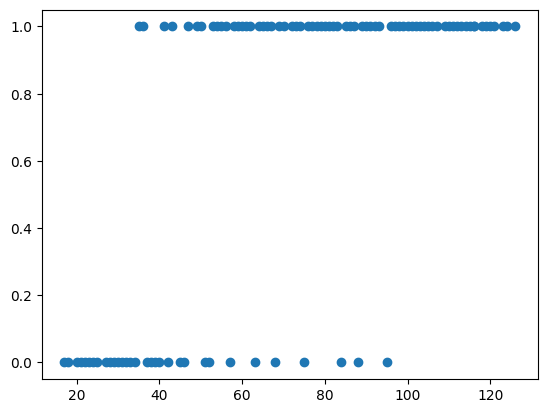

In [227]:
plt.scatter(df.miles_per_week,df.completed_50m_ultra)

<Axes: xlabel='completed_50m_ultra', ylabel='count'>

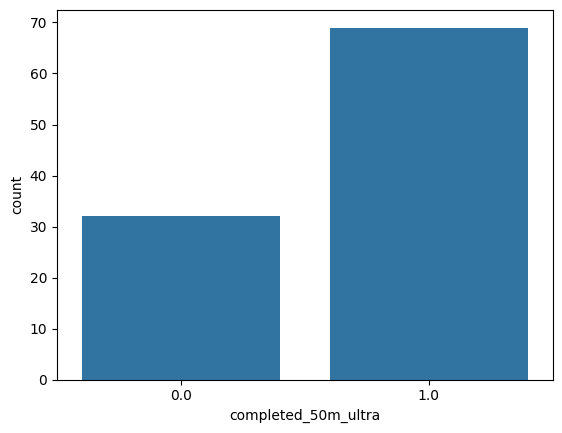

In [228]:
sns.countplot(x= 'completed_50m_ultra',data=df)

In [229]:
X = df.iloc[:, 0:1]
y = df.iloc[:,1]
display(X)
display(y)

,miles_per_week
0,37
1,39
2,46
3,51
4,88
...,...
96,67
97,74
98,79
99,90


,completed_50m_ultra
0,0.0
1,0.0
2,0.0
3,0.0
4,0.0
...,...
96,1.0
97,1.0
98,1.0
99,1.0


In [230]:
X_train, X_test, y_train, y_test = train_test_split(X, y,train_size=0.8, random_state=11)

In [231]:
model = LogisticRegression()

In [232]:
model.fit(X_train, y_train)

LogisticRegression()

In [233]:
y_pred = model.predict(X_test)
y_pred

array([1., 1., 0., 1., 1., 1., 1., 0., 0., 1., 1., 1., 1., 1., 0., 1., 1.,
       0., 1., 1., 0.])

In [234]:
model.score(X_test,y_test)

0.9047619047619048

## **Confusion matrix**

Predicted value is True and Actual Value is True => **True Positive**

Predicted value is True and Actual Value is Flase => **False positive**

Predicted value is Flase and Actual Value is False => **True Negative**

Predicted value is False and Actual Value is True => **False Negative**

In [235]:
print(confusion_matrix(y_test, y_pred))

[[ 5  1]
 [ 1 14]]


In [236]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         0.0       0.83      0.83      0.83         6
         1.0       0.93      0.93      0.93        15

    accuracy                           0.90        21
   macro avg       0.88      0.88      0.88        21
weighted avg       0.90      0.90      0.90        21



# **Working of Logistic Regression**


### **The Sigmoid Function**

y = sigma(x) = 1 / (1 + e^-(x))

for a dataset with 3 features

y = sigma(x1, x2, x3) = 1 / (1 + e^-(ix1 + jx2 + kx3 + B))

where i, j ,k are weights and B is Bias.

**For Any value X, the sigmoid function would return a result between 1 and 0**

In [1]:
import numpy as np

def sigmoid_func(x):
  return 1/ (1 + np.exp(-x))

# **Binary Cross Entropy(Log Loss):**

Why is BCE preferred over MSE(Mean Squared Error)

The important thing to keep in mind before learning why is that no matter what, in a logistic regression model, ***the maximum value can only be 1***.

Example Data

predicted value of a student X Passing is 0.2

predicted value of a student Y Passing is 0.01

If both of them Passed i.e, the output being 1(actual value). Let's see how The Error Calculation works for MSE and BCE.

For MSE:

(1 - 0.2)^2 = 0.64

(1 - 0.01)^2 = 0.9801

we can observe that

*   For the probablities being very different, the error is almost same(not so much difference) for both
*   the penalties(error) does not exceed the value 1.

For BCE:

Given by the formula :

# **(-(Y x nlog(p) + (1 - Y) x nlog(1 - p)))**

Important: Take Natural Log

where:

Y - actual value

p - predicted value

Application:

-(1 x nlog(0.2)) + **((1-1) x (nlog(1-0.2)))** = 1.6094

-(1 x nlog(0.01)) + **((1-1) x (nlog(1- 0.01)))** = 4.6051

Now, we got error values penalized perfectly(implying significant difference) and over 1. unlike MSE.

(intentionally bolded sections of the formula reveal what happens when the actual value is 1 or 0

section 1 - not bolded

section 2 - bolded

-(1 x nlog(0.01)) + **((1-1) x (nlog(1- 0.01)))**

when actual value is 1, section 2 cancels out

when actual value is 0, section 1 cancels out
)


During Training Phase, when we perform p-y = error , we are finding the log loss.

# **From Scratch With Simple Dataset.**

**Updating Weights**

1) initialize Weights and Bias to 0(we initialize random values in NN).
2) initialize learning rate = 0.1 (lr)
3) (dot product weights . sample) + b= predicted value(p)
4) perform sigmoid function for predicted value (x = p)
5) find error = predicted value - actual value
6) error x  value of Xi = P
7) Update weights and bias

        new weight = old weight - (lr x P)

        new bias = old bias - (lr x err)


In [141]:
x1 = np.array([[1,2,3]])
x2 = np.array([[-1,0,2]])
y1 = np.array([[1]])
y2 = np.array([[0]])

w = np.array([[0,0,0]], dtype = float)
b = np.array([[0]], dtype = float)
lr = 0.1

In [142]:
def weights(x, y, w, b, lr):
  yp = np.dot(x,w.T) + b
  print("predicted value of ",x,"with weights",w,"+b",b,"=",yp)
  sigm = sigmoid_func(yp)
  print("value of predicted value after applying sigmoid value = ", sigm)
  err = sigm - y
  print("error = ",sigm,"-",y,"=",err)
  for i in range(0, len(x[0])):
    P = x[0][i] * err
    print("error x Actual Value = ", err, " x ",x[0][i]," = ", P)
    w_new = w[0][i] - (lr * P)
    print("Updated weight = ", w[0][i],"-(",lr,"x",P,")=",w_new)
    w[0][i] = w_new
  b_new = b - (lr * err)
  print("Updated bias = ", b, "-(",lr,"x",err,")=", b_new)
  b[0][0] = b_new

In [143]:
weights(x1, y1, w, b, lr)

predicted value of  [[1 2 3]] with weights [[0. 0. 0.]] +b [[0.]] = [[0.]]
value of predicted value after applying sigmoid value =  [[0.5]]
error =  [[0.5]] - [[1]] = [[-0.5]]
error x Actual Value =  [[-0.5]]  x  1  =  [[-0.5]]
Updated weight =  0.0 -( 0.1 x [[-0.5]] )= [[0.05]]
error x Actual Value =  [[-0.5]]  x  2  =  [[-1.]]
Updated weight =  0.0 -( 0.1 x [[-1.]] )= [[0.1]]
error x Actual Value =  [[-0.5]]  x  3  =  [[-1.5]]
Updated weight =  0.0 -( 0.1 x [[-1.5]] )= [[0.15]]
Updated bias =  [[0.]] -( 0.1 x [[-0.5]] )= [[0.05]]


/tmp/ipykernel_929/70637210.py:13: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  w[0][i] = w_new
/tmp/ipykernel_929/70637210.py:16: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  b[0][0] = b_new


In [144]:
w #updated weight

array([[0.05, 0.1 , 0.15]])

In [145]:
weights(x2, y2, w, b, lr)

predicted value of  [[-1  0  2]] with weights [[0.05 0.1  0.15]] +b [[0.05]] = [[0.3]]
value of predicted value after applying sigmoid value =  [[0.57444252]]
error =  [[0.57444252]] - [[0]] = [[0.57444252]]
error x Actual Value =  [[0.57444252]]  x  -1  =  [[-0.57444252]]
Updated weight =  0.05 -( 0.1 x [[-0.57444252]] )= [[0.10744425]]
error x Actual Value =  [[0.57444252]]  x  0  =  [[0.]]
Updated weight =  0.1 -( 0.1 x [[0.]] )= [[0.1]]
error x Actual Value =  [[0.57444252]]  x  2  =  [[1.14888503]]
Updated weight =  0.15000000000000002 -( 0.1 x [[1.14888503]] )= [[0.0351115]]
Updated bias =  [[0.05]] -( 0.1 x [[0.57444252]] )= [[-0.00744425]]


/tmp/ipykernel_929/70637210.py:13: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  w[0][i] = w_new
/tmp/ipykernel_929/70637210.py:16: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  b[0][0] = b_new


In [146]:
w

array([[0.10744425, 0.1       , 0.0351115 ]])

In [147]:
weight_vector = np.concatenate((b,w), axis=1)
weight_vector

array([[-0.00744425,  0.10744425,  0.1       ,  0.0351115 ]])

In [148]:
def ready_sample(x):
  #for a sample being np.array([[x1,x2,x3]]) convert to ([[1,x1,x2,x3]])
  return np.concatenate((np.array([[1]]), x), axis=1)

In [150]:
ready_x1 = ready_sample(x1)
print(f"Original x1: {x1}")
print(f"Ready x1 (with prepended 1): {ready_x1}")

Original x1: [[1 2 3]]
Ready x1 (with prepended 1): [[1 1 2 3]]


In [151]:
ready_x2 = ready_sample(x2)
print(f"Original x2: {x2}")
print(f"Ready x2 (with prepended 1): {ready_x2}")

Original x2: [[-1  0  2]]
Ready x2 (with prepended 1): [[ 1 -1  0  2]]


In [155]:
y1_test_logits = np.dot(ready_x1, weight_vector.T)
y1_test_logits

array([[0.40533449]])

In [156]:
y2_test_logits = np.dot(ready_x2, weight_vector.T)
y2_test_logits

array([[-0.04466551]])

In [160]:
print("Sample 1 Probability:", sigmoid_func(y1_test_logits)) #closer to 1
print("Sample 2 Probability:",sigmoid_func(y2_test_logits)) #closer to 0
# the weights are learning for just 2 samples!

Sample 1 Probability: [[0.59996865]]
Sample 2 Probability: [[0.48883548]]
